In [108]:
import importlib
import train
import evaluator
import numpy as np
import torch

# Reload for fresh edits
importlib.reload(train)
importlib.reload(evaluator)

from train import generate_data, train, evaluate,plot_hypothesis_scores
from evaluator import EFTReweighter

In [110]:
# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
wc_dim = 16
N = 10
M = 50000
theta1 = [0.0] * wc_dim
step = 0  # Use 8 for reco
VARS = [
    "gen_ttbar_mass",            # m_ttbar
    "gen_ll_cHel"                # cos(theta*_r)
]

mass_regions = ["0to700", "700to900", "900toInf"]
cross_sections = {"0to700": 65.09, "700to900": 8.295, "900toInf": 14.03}
directory = "/eos/purdue/store/user/lingqian/fullrun2_eft_minitrees"
struct_dir = "/eos/purdue/store/user/lingqian/fullrun2_eft_sc"
eras = ["2016preVFP"]
channels = ["ee", "emu", "mumu"]

# Create reweighter
reweighter = EFTReweighter(
    directory_path=directory,
    eras=eras,
    channels=channels,
    mass_regions=mass_regions,
    cross_sections=cross_sections,
    struct_const_dir=struct_dir,
    step=step
)



In [111]:
reweighter.load_structure_constants()
reweighter.load_observables()


Loading step0 structure constants: 100%|██████████| 9/9 [00:27<00:00,  3.09s/it]


Structure constants loaded.


Loading observables: 100%|██████████| 9/9 [00:24<00:00,  2.76s/file]


In [112]:
# Generate training data
X_all, Y_all = [], []
for X, Y in generate_data(reweighter, VARS, wc_dim, N=N, M=M, theta1=theta1):
    X_all.append(X)
    Y_all.append(Y)

X_all = np.vstack(X_all)
Y_all = np.hstack(Y_all)


In [115]:
X_all

array([[ 4.20386536e+02,  3.50396991e-01, -2.00000000e+00],
       [ 4.65656860e+02, -2.50789464e-01, -2.00000000e+00],
       [ 3.54484863e+02,  8.63408446e-01, -2.00000000e+00],
       ...,
       [ 5.67999817e+02,  6.03531539e-01,  0.00000000e+00],
       [ 4.83464508e+02,  8.92061472e-01,  0.00000000e+00],
       [ 4.93273254e+02,  4.99093026e-01,  0.00000000e+00]])

Epoch 1: Train 0.0301, Val 0.0000


Epoch 2: Train 0.0008, Val 0.0003


Epoch 3: Train 0.0002, Val 0.0000


Epoch 4: Train 0.0002, Val 0.0000


Epoch 5: Train 0.0002, Val 0.0000


...

Epoch 16: Train 0.0000, Val 0.0000


Epoch 17: Train 0.0002, Val 0.0000


Epoch 18: Train 0.0000, Val 0.0000


Epoch 19: Train 0.0000, Val 0.0000


Epoch 20: Train 0.0000, Val 0.0000


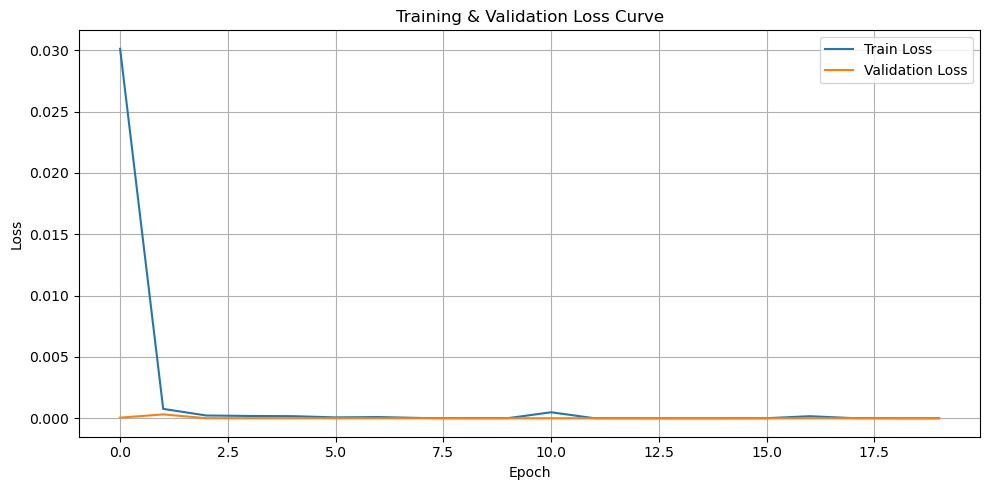

In [113]:
# Train model
model, scaler, (X_test, Y_test) = train(X_all, Y_all, VARS, device=device)

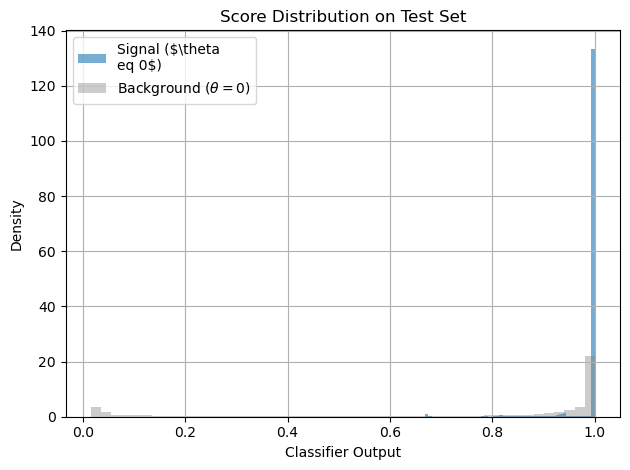

In [114]:
evaluate(model, scaler, X_test, Y_test, device=device)
